# LangGraph Evol-Instruct Synthetic Data Generation

## Advanced Build: Agent-Based Question Evolution

This notebook implements a **LangGraph-based Evol-Instruct synthetic data generation system** that replaces the traditional RAGAS Knowledge Graph approach with intelligent agent-based question evolution.

### 🎯 **Key Features:**
- **Evol-Instruct Methodology**: Progressive instruction evolution from simple to complex
- **Three Evolution Types**: Simple, Multi-Context, and Reasoning Evolution  
- **Agent-Based Architecture**: LangGraph agents orchestrate the entire process
- **Document-Driven**: Uses same documents from "data" folder as original SDG system

### 🏗️ **Architecture Overview:**
```
📥 Input Documents → 🔍 Document Analyzer → 🌱 Question Evolution → 📝 Answer Generation → 📋 Context Retrieval → 📤 Output
```

### 🎯 **Expected Output:**
- `List[dict]`: Evolved Questions with IDs and Evolution Types
- `List[dict]`: Question IDs with Answers  
- `List[dict]`: Question IDs with Relevant Contexts


## 1. Dependencies and Setup

First, let's install the required dependencies for our LangGraph Evol-Instruct system.


In [50]:
# Install required dependencies
%pip install langgraph langchain langchain-openai langchain-community python-dotenv


/Users/anilyanamandra/Develop/aie8/AI-Engineering-Bootcamp/07_Synthetic_Data_Generation_and_LangSmith/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [51]:
# Load environment variables
from dotenv import load_dotenv
import os
from uuid import uuid4

load_dotenv()

# Set up LangSmith tracing
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = f"LangGraph-EvolInstruct-SDG-{uuid4().hex[0:8]}"

# Verify environment variables
required_vars = ['LANGCHAIN_API_KEY', 'OPENAI_API_KEY']
missing_vars = []

for var in required_vars:
    if not os.getenv(var):
        missing_vars.append(var)

if missing_vars:
    print(f"⚠️  Missing environment variables: {', '.join(missing_vars)}")
    print("Please check your .env file and ensure all required variables are set.")
else:
    print("✅ All required environment variables loaded successfully!")
    print(f"📊 LangSmith tracing enabled for project: {os.environ['LANGCHAIN_PROJECT']}")


✅ All required environment variables loaded successfully!
📊 LangSmith tracing enabled for project: LangGraph-EvolInstruct-SDG-539e656b


In [52]:
# Import required libraries
import uuid
from typing import List, Dict, Any, TypedDict, Annotated
from dataclasses import dataclass
from enum import Enum

# LangChain imports
from langchain_core.documents import Document
from langchain_community.document_loaders import DirectoryLoader, PyMuPDFLoader
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# LangGraph imports
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver

print("✅ All imports loaded successfully!")


✅ All imports loaded successfully!


## 2. Load Test Documents

Load the same documents from the "data" folder that were used in the original RAGAS SDG system.


In [53]:
# Load documents from data folder (same as original SDG system)
path = "data/"
loader = DirectoryLoader(path, glob="*.pdf", loader_cls=PyMuPDFLoader)
docs = loader.load()

print(f"📄 Loaded {len(docs)} documents from data folder")
print(f"📊 Total pages: {sum(len(doc.page_content.split()) for doc in docs)} words")

# Display document metadata
for i, doc in enumerate(docs[:3]):  # Show first 3 documents
    print(f"\n📋 Document {i+1}:")
    print(f"   Source: {doc.metadata.get('source', 'Unknown')}")
    print(f"   Content length: {len(doc.page_content)} characters")
    print(f"   Preview: {doc.page_content[:200]}...")


📄 Loaded 64 documents from data folder
📊 Total pages: 17509 words

📋 Document 1:
   Source: data/howpeopleuseai.pdf
   Content length: 1672 characters
   Preview: NBER WORKING PAPER SERIES
HOW PEOPLE USE CHATGPT
Aaron Chatterji
Thomas Cunningham
David J. Deming
Zoe Hitzig
Christopher Ong
Carl Yan Shan
Kevin Wadman
Working Paper 34255
http://www.nber.org/papers/...

📋 Document 2:
   Source: data/howpeopleuseai.pdf
   Content length: 2051 characters
   Preview: How People Use ChatGPT
Aaron Chatterji, Thomas Cunningham, David J. Deming, Zoe Hitzig, Christopher Ong, Carl
Yan Shan, and Kevin Wadman
NBER Working Paper No. 34255
September 2025
JEL No. J01, O3, O4...

📋 Document 3:
   Source: data/howpeopleuseai.pdf
   Content length: 3823 characters
   Preview: 1
Introduction
ChatGPT launched in November 2022. By July 2025, 18 billion messages were being sent each week
by 700 million users, representing around 10% of the global adult population.1 For a new t...


## 3. Define Evolution Types and Data Structures

Define the three evolution types and the state management structure for our LangGraph system.


In [54]:
# Define Evolution Types
class EvolutionType(Enum):
    SIMPLE = "simple"
    MULTI_CONTEXT = "multi_context" 
    REASONING = "reasoning"

# Define data structures for our outputs
@dataclass
class EvolvedQuestion:
    id: str
    question: str
    evolution_type: EvolutionType
    evolution_steps: List[str]
    original_question: str = None

@dataclass
class QuestionAnswer:
    question_id: str
    answer: str
    reasoning: str = None

@dataclass
class QuestionContext:
    question_id: str
    contexts: List[str]
    context_sources: List[str] = None

# Define the state for our LangGraph
class EvolutionState(TypedDict):
    documents: List[Document]
    analyzed_docs: Dict[str, Any]
    base_questions: List[str]
    evolved_questions: List[EvolvedQuestion]
    answers: List[QuestionAnswer]
    contexts: List[QuestionContext]
    current_evolution_type: EvolutionType
    evolution_step: int
    llm_model: ChatOpenAI

print("✅ Data structures and evolution types defined!")


✅ Data structures and evolution types defined!


## 4. Initialize LLM and Evolution Prompts

Set up the LLM model and create prompts for the Evol-Instruct methodology.


In [55]:
# Initialize LLM model
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.7,
    max_tokens=2000
)

# Define evolution prompts for each type
EVOLUTION_PROMPTS = {
    EvolutionType.SIMPLE: ChatPromptTemplate.from_template("""
You are an expert at evolving simple questions into more sophisticated ones.

Given this document content:
{content}

Original question: {question}

Evolve this question through the following steps:
1. Make it more specific and detailed
2. Add context about the domain/topic
3. Increase complexity while maintaining clarity

Provide the evolved question and the evolution steps taken.
Format your response as:
EVOLVED_QUESTION: [new question]
STEPS: [list of evolution steps taken]
"""),

    EvolutionType.MULTI_CONTEXT: ChatPromptTemplate.from_template("""
You are an expert at creating questions that require information from multiple documents.

Document 1: {doc1_content}
Document 2: {doc2_content}

Original question: {question}

Evolve this question to require information from BOTH documents:
1. Make it comparative or analytical
2. Require synthesis of information from both sources
3. Create a question that cannot be answered from just one document

Provide the evolved question and the evolution steps taken.
Format your response as:
EVOLVED_QUESTION: [new question]
STEPS: [list of evolution steps taken]
"""),

    EvolutionType.REASONING: ChatPromptTemplate.from_template("""
You are an expert at creating questions that require complex reasoning and inference.

Given this document content:
{content}

Original question: {question}

Evolve this question to require:
1. Logical reasoning and inference
2. Analysis of implications or consequences
3. Evaluation or judgment based on evidence
4. Critical thinking about trade-offs or alternatives

Provide the evolved question and the evolution steps taken.
Format your response as:
EVOLVED_QUESTION: [new question]
STEPS: [list of evolution steps taken]
""")
}

print("✅ LLM model and evolution prompts initialized!")


✅ LLM model and evolution prompts initialized!


## 5. Create LangGraph Agent Nodes

Implement the agent nodes that will handle document analysis, question evolution, answer generation, and context retrieval.


In [56]:
# Node 1: Document Analyzer
def analyze_documents(state: EvolutionState) -> EvolutionState:
    """Analyze documents and extract key information for question generation."""
    
    print(f"\n🔍 **DOCUMENT ANALYZER NODE STARTED**")
    print(f"   📄 Processing {len(state['documents'])} documents...")
    
    analyzed_docs = {}
    
    for i, doc in enumerate(state["documents"]):
        print(f"   Analyzing document {i+1}/{len(state['documents'])}: {doc.metadata.get('source', f'Document_{i}')}")
        
        # Extract key information from each document
        content = doc.page_content[:2000]  # Limit content for analysis
        
        # Simple analysis - extract key topics and concepts
        analysis_prompt = ChatPromptTemplate.from_template("""
        Analyze this document and extract:
        1. Main topics and themes
        2. Key concepts and terms
        3. Important facts or statistics
        4. Potential question areas
        
        Document content:
        {content}
        
        Provide a structured analysis.
        """)
        
        chain = analysis_prompt | state["llm_model"] | StrOutputParser()
        analysis = chain.invoke({"content": content})
        
        analyzed_docs[f"doc_{i}"] = {
            "source": doc.metadata.get("source", f"Document_{i}"),
            "content": content,
            "analysis": analysis,
            "full_content": doc.page_content
        }
    
    state["analyzed_docs"] = analyzed_docs
    print(f"🔍 **DOCUMENT ANALYZER COMPLETED**")
    print(f"   ✅ Successfully analyzed {len(state['documents'])} documents")
    print(f"   📊 Ready for question generation phase")
    return state


In [57]:
# Node 2: Base Question Generator
def generate_base_questions(state: EvolutionState) -> EvolutionState:
    """Generate initial base questions from analyzed documents."""
    
    print(f"\n❓ **BASE QUESTION GENERATOR NODE STARTED**")
    print(f"   📚 Processing {len(state['analyzed_docs'])} analyzed documents...")
    
    base_questions = []
    
    # Generate questions from each document
    for i, (doc_key, doc_info) in enumerate(state["analyzed_docs"].items()):
        print(f"   📋 Generating questions for document {i+1}/{len(state['analyzed_docs'])}: {doc_info['source']}")
        
        question_prompt = ChatPromptTemplate.from_template("""
        Based on this document analysis, generate 3-5 initial questions that could be asked about this content.
        Make them simple and direct.
        
        Document analysis:
        {analysis}
        
        Generate questions that cover:
        1. Basic factual questions
        2. Definition questions
        3. Process/How questions
        
        Format: List each question on a new line starting with "Q: "
        """)
        
        print(f"      🤖 Calling LLM for question generation...")
        chain = question_prompt | state["llm_model"] | StrOutputParser()
        questions_text = chain.invoke({"analysis": doc_info["analysis"]})
        
        # Parse questions from response
        questions = [q.strip() for q in questions_text.split("Q: ") if q.strip()]
        base_questions.extend(questions)
        
        print(f"      ✅ Generated {len(questions)} questions from {doc_info['source']}")
        for j, q in enumerate(questions, 1):
            print(f"         {j}. {q[:80]}{'...' if len(q) > 80 else ''}")
    
    state["base_questions"] = base_questions
    print(f"❓ **BASE QUESTION GENERATOR COMPLETED**")
    print(f"   ✅ Successfully generated {len(base_questions)} base questions")
    print(f"   📊 Ready for evolution phase")
    return state


In [58]:
# Node 3: Question Evolution Router
def route_evolution_type(state: EvolutionState) -> str:
    """Route to appropriate evolution type based on current step."""
    
    current_step = state["evolution_step"]
    print(f"\n🔀 **ROUTER NODE EXECUTED**")
    print(f"   📊 Current evolution step: {current_step}")
    
    if current_step == 0:
        print(f"   🎯 Routing to: Simple Evolution")
        return "simple_evolution"
    elif current_step == 1:
        print(f"   🎯 Routing to: Multi-Context Evolution")
        return "multi_context_evolution"  
    elif current_step == 2:
        print(f"   🎯 Routing to: Reasoning Evolution")
        return "reasoning_evolution"
    else:
        print(f"   🎯 Routing to: Answer Generation (evolution complete)")
        return "generate_answers"


In [59]:
# Node 4: Simple Evolution
def simple_evolution(state: EvolutionState) -> EvolutionState:
    """Apply simple evolution to questions."""
    
    print(f"\n🌱 **SIMPLE EVOLUTION NODE STARTED**")
    print(f"   📊 Current evolution step: {state['evolution_step']}")
    print(f"   🎯 Processing questions for Simple Evolution...")
    
    evolved_questions = []
    doc_info = list(state["analyzed_docs"].values())[0]  # Use first document
    questions_to_process = state["base_questions"][:5]  # Limit to 5 questions
    
    print(f"   📝 Processing {len(questions_to_process)} questions for simple evolution")
    
    for i, question in enumerate(questions_to_process):
        print(f"   🔄 Evolving question {i+1}/{len(questions_to_process)}")
        print(f"      📋 Original: {question[:60]}{'...' if len(question) > 60 else ''}")
        
        print(f"      🤖 Calling LLM for simple evolution...")
        chain = EVOLUTION_PROMPTS[EvolutionType.SIMPLE] | state["llm_model"] | StrOutputParser()
        
        response = chain.invoke({
            "content": doc_info["content"],
            "question": question
        })
        
        # Parse response
        lines = response.split("\n")
        evolved_question = ""
        steps = []
        
        for line in lines:
            if line.startswith("EVOLVED_QUESTION:"):
                evolved_question = line.replace("EVOLVED_QUESTION:", "").strip()
            elif line.startswith("STEPS:"):
                steps_text = line.replace("STEPS:", "").strip()
                steps = [s.strip() for s in steps_text.split(",") if s.strip()]
        
        if evolved_question:
            evolved_q = EvolvedQuestion(
                id=f"simple_{uuid.uuid4().hex[:8]}",
                question=evolved_question,
                evolution_type=EvolutionType.SIMPLE,
                evolution_steps=steps,
                original_question=question
            )
            evolved_questions.append(evolved_q)
            
            print(f"      ✅ Evolution complete!")
            print(f"         🎯 Evolved: {evolved_question[:60]}{'...' if len(evolved_question) > 60 else ''}")
            print(f"         📈 Steps: {', '.join(steps[:2])}{'...' if len(steps) > 2 else ''}")
        else:
            print(f"      ⚠️  Evolution failed - no valid response")
    
    state["evolved_questions"].extend(evolved_questions)
    state["evolution_step"] += 1
    
    print(f"🌱 **SIMPLE EVOLUTION COMPLETED**")
    print(f"   ✅ Successfully evolved {len(evolved_questions)} questions")
    print(f"   📊 Evolution step incremented to: {state['evolution_step']}")
    print(f"   🎯 Ready for conditional routing...")
    return state


In [60]:
# Node 5: Multi-Context Evolution
def multi_context_evolution(state: EvolutionState) -> EvolutionState:
    """Apply multi-context evolution to questions."""
    
    print(f"\n🔄 **MULTI-CONTEXT EVOLUTION NODE STARTED**")
    print(f"   📊 Current evolution step: {state['evolution_step']}")
    print(f"   🎯 Processing questions for Multi-Context Evolution...")
    
    evolved_questions = []
    doc_infos = list(state["analyzed_docs"].values())
    
    if len(doc_infos) >= 2:
        doc1, doc2 = doc_infos[0], doc_infos[1]
        questions_to_process = state["base_questions"][:3]  # Limit to 3 questions
        
        print(f"   📚 Using {len(doc_infos)} documents for multi-context analysis")
        print(f"   📝 Processing {len(questions_to_process)} questions for multi-context evolution")
        
        for i, question in enumerate(questions_to_process):
            print(f"   🔄 Evolving question {i+1}/{len(questions_to_process)}")
            print(f"      📋 Original: {question[:60]}{'...' if len(question) > 60 else ''}")
            
            print(f"      🤖 Calling LLM for multi-context evolution...")
            chain = EVOLUTION_PROMPTS[EvolutionType.MULTI_CONTEXT] | state["llm_model"] | StrOutputParser()
            
            response = chain.invoke({
                "doc1_content": doc1["content"],
                "doc2_content": doc2["content"],
                "question": question
            })
            
            # Parse response
            lines = response.split("\n")
            evolved_question = ""
            steps = []
            
            for line in lines:
                if line.startswith("EVOLVED_QUESTION:"):
                    evolved_question = line.replace("EVOLVED_QUESTION:", "").strip()
                elif line.startswith("STEPS:"):
                    steps_text = line.replace("STEPS:", "").strip()
                    steps = [s.strip() for s in steps_text.split(",") if s.strip()]
            
            if evolved_question:
                evolved_q = EvolvedQuestion(
                    id=f"multi_{uuid.uuid4().hex[:8]}",
                    question=evolved_question,
                    evolution_type=EvolutionType.MULTI_CONTEXT,
                    evolution_steps=steps,
                    original_question=question
                )
                evolved_questions.append(evolved_q)
                
                print(f"      ✅ Multi-context evolution complete!")
                print(f"         🎯 Evolved: {evolved_question[:60]}{'...' if len(evolved_question) > 60 else ''}")
                print(f"         📈 Steps: {', '.join(steps[:2])}{'...' if len(steps) > 2 else ''}")
            else:
                print(f"      ⚠️  Multi-context evolution failed - no valid response")
    else:
        print(f"   ⚠️  Insufficient documents for multi-context evolution (need at least 2)")
    
    state["evolved_questions"].extend(evolved_questions)
    state["evolution_step"] += 1
    
    print(f"🔄 **MULTI-CONTEXT EVOLUTION COMPLETED**")
    print(f"   ✅ Successfully evolved {len(evolved_questions)} questions")
    print(f"   📊 Evolution step incremented to: {state['evolution_step']}")
    print(f"   🎯 Ready for conditional routing...")
    return state


In [61]:
# Node 6: Reasoning Evolution
def reasoning_evolution(state: EvolutionState) -> EvolutionState:
    """Apply reasoning evolution to questions."""
    
    print(f"\n🧠 **REASONING EVOLUTION NODE STARTED**")
    print(f"   📊 Current evolution step: {state['evolution_step']}")
    print(f"   🎯 Processing questions for Reasoning Evolution...")
    
    evolved_questions = []
    doc_info = list(state["analyzed_docs"].values())[0]  # Use first document
    questions_to_process = state["base_questions"][:3]  # Limit to 3 questions
    
    print(f"   📝 Processing {len(questions_to_process)} questions for reasoning evolution")
    
    for i, question in enumerate(questions_to_process):
        print(f"   🔄 Evolving question {i+1}/{len(questions_to_process)}")
        print(f"      📋 Original: {question[:60]}{'...' if len(question) > 60 else ''}")
        
        print(f"      🤖 Calling LLM for reasoning evolution...")
        chain = EVOLUTION_PROMPTS[EvolutionType.REASONING] | state["llm_model"] | StrOutputParser()
        
        response = chain.invoke({
            "content": doc_info["content"],
            "question": question
        })
        
        # Parse response
        lines = response.split("\n")
        evolved_question = ""
        steps = []
        
        for line in lines:
            if line.startswith("EVOLVED_QUESTION:"):
                evolved_question = line.replace("EVOLVED_QUESTION:", "").strip()
            elif line.startswith("STEPS:"):
                steps_text = line.replace("STEPS:", "").strip()
                steps = [s.strip() for s in steps_text.split(",") if s.strip()]
        
        if evolved_question:
            evolved_q = EvolvedQuestion(
                id=f"reasoning_{uuid.uuid4().hex[:8]}",
                question=evolved_question,
                evolution_type=EvolutionType.REASONING,
                evolution_steps=steps,
                original_question=question
            )
            evolved_questions.append(evolved_q)
            
            print(f"      ✅ Reasoning evolution complete!")
            print(f"         🎯 Evolved: {evolved_question[:60]}{'...' if len(evolved_question) > 60 else ''}")
            print(f"         📈 Steps: {', '.join(steps[:2])}{'...' if len(steps) > 2 else ''}")
        else:
            print(f"      ⚠️  Reasoning evolution failed - no valid response")
    
    state["evolved_questions"].extend(evolved_questions)
    state["evolution_step"] += 1
    
    print(f"🧠 **REASONING EVOLUTION COMPLETED**")
    print(f"   ✅ Successfully evolved {len(evolved_questions)} questions")
    print(f"   📊 Evolution step incremented to: {state['evolution_step']}")
    print(f"   🎯 Ready for conditional routing...")
    return state


In [62]:
# Node 7: Answer Generation
def generate_answers(state: EvolutionState) -> EvolutionState:
    """Generate answers for evolved questions."""
    
    print(f"\n📝 **ANSWER GENERATION NODE STARTED**")
    print(f"   📊 Processing {len(state['evolved_questions'])} evolved questions...")
    
    answers = []
    all_content = " ".join([doc["full_content"] for doc in state["analyzed_docs"].values()])
    
    print(f"   📚 Using {len(state['analyzed_docs'])} documents for answer generation")
    print(f"   📄 Total content length: {len(all_content)} characters")
    
    answer_prompt = ChatPromptTemplate.from_template("""
    Answer the following question based on the provided document content.
    Provide a comprehensive and accurate answer.
    
    Question: {question}
    
    Document Content:
    {content}
    
    Answer:
    """)
    
    for i, evolved_q in enumerate(state["evolved_questions"]):
        print(f"   🔄 Generating answer {i+1}/{len(state['evolved_questions'])}")
        print(f"      📋 Question ID: {evolved_q.id}")
        print(f"      🎯 Evolution Type: {evolved_q.evolution_type.value}")
        print(f"      ❓ Question: {evolved_q.question[:60]}{'...' if len(evolved_q.question) > 60 else ''}")
        
        print(f"      🤖 Calling LLM for answer generation...")
        chain = answer_prompt | state["llm_model"] | StrOutputParser()
        
        answer = chain.invoke({
            "question": evolved_q.question,
            "content": all_content
        })
        
        qa = QuestionAnswer(
            question_id=evolved_q.id,
            answer=answer
        )
        answers.append(qa)
        
        print(f"      ✅ Answer generated!")
        print(f"         📝 Answer length: {len(answer)} characters")
        print(f"         📄 Preview: {answer[:80]}{'...' if len(answer) > 80 else ''}")
    
    state["answers"] = answers
    
    print(f"📝 **ANSWER GENERATION COMPLETED**")
    print(f"   ✅ Successfully generated {len(answers)} answers")
    print(f"   📊 Ready for context retrieval phase")
    return state


In [63]:
# Node 8: Context Retrieval
def retrieve_contexts(state: EvolutionState) -> EvolutionState:
    """Retrieve relevant contexts for each question."""
    
    print(f"\n📋 **CONTEXT RETRIEVAL NODE STARTED**")
    print(f"   📊 Processing {len(state['evolved_questions'])} evolved questions...")
    
    contexts = []
    
    # Simple context retrieval - find relevant document chunks
    for i, evolved_q in enumerate(state["evolved_questions"]):
        print(f"   🔄 Retrieving contexts for question {i+1}/{len(state['evolved_questions'])}")
        print(f"      📋 Question ID: {evolved_q.id}")
        print(f"      🎯 Evolution Type: {evolved_q.evolution_type.value}")
        print(f"      ❓ Question: {evolved_q.question[:60]}{'...' if len(evolved_q.question) > 60 else ''}")
        
        relevant_contexts = []
        context_sources = []
        
        print(f"      🔍 Searching through {len(state['analyzed_docs'])} documents...")
        
        # For each document, find chunks that might be relevant
        for doc_key, doc_info in state["analyzed_docs"].items():
            # Simple keyword-based relevance (in a real system, you'd use embeddings)
            content = doc_info["full_content"]
            
            # Split into chunks
            chunk_size = 500
            chunks = [content[i:i+chunk_size] for i in range(0, len(content), chunk_size)]
            
            print(f"         📄 Processing {doc_info['source']} ({len(chunks)} chunks)")
            
            # Find relevant chunks (simple keyword matching)
            question_words = set(evolved_q.question.lower().split())
            
            for chunk_idx, chunk in enumerate(chunks):
                chunk_words = set(chunk.lower().split())
                overlap = len(question_words.intersection(chunk_words))
                
                if overlap > 2:  # Threshold for relevance
                    relevant_contexts.append(chunk)
                    context_sources.append(doc_info["source"])
                    print(f"            ✅ Found relevant chunk {chunk_idx+1} (overlap: {overlap} words)")
        
        # Limit to top 3 contexts
        relevant_contexts = relevant_contexts[:3]
        context_sources = context_sources[:3]
        
        qc = QuestionContext(
            question_id=evolved_q.id,
            contexts=relevant_contexts,
            context_sources=context_sources
        )
        contexts.append(qc)
        
        print(f"      ✅ Context retrieval complete!")
        print(f"         📋 Retrieved {len(relevant_contexts)} relevant contexts")
        print(f"         📚 Sources: {', '.join(set(context_sources))}")
    
    state["contexts"] = contexts
    
    print(f"📋 **CONTEXT RETRIEVAL COMPLETED**")
    print(f"   ✅ Successfully retrieved contexts for {len(contexts)} questions")
    print(f"   📊 LangGraph workflow complete!")
    return state


## 6. Build LangGraph Workflow

Create the LangGraph workflow that orchestrates all the agent nodes.


In [64]:
# Create the LangGraph workflow
def create_evolution_graph():
    """Create the LangGraph workflow for question evolution."""
    
    # Create the state graph
    workflow = StateGraph(EvolutionState)
    
    # Add nodes
    workflow.add_node("analyze_documents", analyze_documents)
    workflow.add_node("generate_base_questions", generate_base_questions)
    workflow.add_node("simple_evolution", simple_evolution)
    workflow.add_node("multi_context_evolution", multi_context_evolution)
    workflow.add_node("reasoning_evolution", reasoning_evolution)
    workflow.add_node("generate_answers", generate_answers)
    workflow.add_node("retrieve_contexts", retrieve_contexts)
    
    # Set entry point
    workflow.set_entry_point("analyze_documents")
    
    # Add edges
    workflow.add_edge("analyze_documents", "generate_base_questions")
    workflow.add_edge("generate_base_questions", "simple_evolution")
    
    # Add conditional routing for evolution types
    workflow.add_conditional_edges(
        "simple_evolution",
        route_evolution_type,
        {
            "simple_evolution": "simple_evolution",
            "multi_context_evolution": "multi_context_evolution",
            "reasoning_evolution": "reasoning_evolution",
            "generate_answers": "generate_answers"
        }
    )
    
    workflow.add_conditional_edges(
        "multi_context_evolution",
        route_evolution_type,
        {
            "simple_evolution": "simple_evolution",
            "multi_context_evolution": "multi_context_evolution", 
            "reasoning_evolution": "reasoning_evolution",
            "generate_answers": "generate_answers"
        }
    )
    
    workflow.add_conditional_edges(
        "reasoning_evolution",
        route_evolution_type,
        {
            "simple_evolution": "simple_evolution",
            "multi_context_evolution": "multi_context_evolution",
            "reasoning_evolution": "reasoning_evolution", 
            "generate_answers": "generate_answers"
        }
    )
    
    workflow.add_edge("generate_answers", "retrieve_contexts")
    workflow.add_edge("retrieve_contexts", END)
    
    return workflow.compile()


In [65]:
# Display the LangGraph Mermaid visualization
from IPython.display import display, Markdown

# Get the Mermaid graph
graph_info = graph.get_graph()
mermaid_graph = graph_info.draw_mermaid()

# Display as Mermaid diagram
display(Markdown(f"""
```mermaid
{mermaid_graph}
```
"""))



```mermaid
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	analyze_documents(analyze_documents)
	generate_base_questions(generate_base_questions)
	simple_evolution(simple_evolution)
	multi_context_evolution(multi_context_evolution)
	reasoning_evolution(reasoning_evolution)
	generate_answers(generate_answers)
	retrieve_contexts(retrieve_contexts)
	__end__([<p>__end__</p>]):::last
	__start__ --> analyze_documents;
	analyze_documents --> generate_base_questions;
	generate_answers --> retrieve_contexts;
	generate_base_questions --> simple_evolution;
	multi_context_evolution -.-> generate_answers;
	multi_context_evolution -.-> reasoning_evolution;
	multi_context_evolution -.-> simple_evolution;
	reasoning_evolution -.-> generate_answers;
	reasoning_evolution -.-> multi_context_evolution;
	reasoning_evolution -.-> simple_evolution;
	simple_evolution -.-> generate_answers;
	simple_evolution -.-> multi_context_evolution;
	simple_evolution -.-> reasoning_evolution;
	retrieve_contexts --> __end__;
	multi_context_evolution -.-> multi_context_evolution;
	reasoning_evolution -.-> reasoning_evolution;
	simple_evolution -.-> simple_evolution;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc

```


Generating single mermaid chart
✅ Mermaid diagram converted to PNG using mermaid-cli


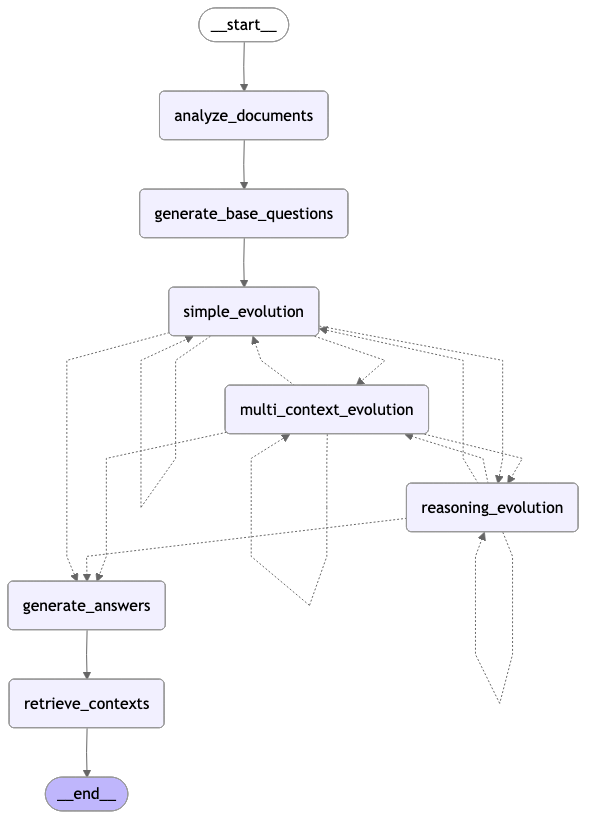

In [66]:
# Convert Mermaid diagram to PNG
import subprocess
import os
from IPython.display import Image, display

# Get the Mermaid graph
graph_info = graph.get_graph()
mermaid_graph = graph_info.draw_mermaid()

# Save Mermaid code to file
with open('workflow.mmd', 'w') as f:
    f.write(mermaid_graph)

# Try to convert to PNG using mermaid-cli if available
try:
    # Check if mermaid-cli is available
    result = subprocess.run(['mmdc', '--version'], capture_output=True, text=True)
    if result.returncode == 0:
        # Convert to PNG using mermaid-cli
        subprocess.run(['mmdc', '-i', 'workflow.mmd', '-o', 'langgraph_workflow.png', '-t', 'neutral', '-b', 'white'], check=True)
        print("✅ Mermaid diagram converted to PNG using mermaid-cli")
        display(Image('langgraph_workflow.png'))
    else:
        raise FileNotFoundError("mermaid-cli not found")
        
except (FileNotFoundError, subprocess.CalledProcessError):
    # Fallback: Use online Mermaid service or provide instructions
    print("📊 Mermaid diagram generated. To convert to PNG:")
    print("1. Copy the Mermaid code below")
    print("2. Go to https://mermaid.live/")
    print("3. Paste the code and export as PNG")
    print("\nMermaid Code:")
    print("```mermaid")
    print(mermaid_graph)
    print("```")
    
    # Also save the mermaid file for manual conversion
    print(f"\n💾 Mermaid file saved as 'workflow.mmd'")
    print("You can convert it manually using:")
    print("npm install -g @mermaid-js/mermaid-cli")
    print("mmdc -i workflow.mmd -o langgraph_workflow.png")


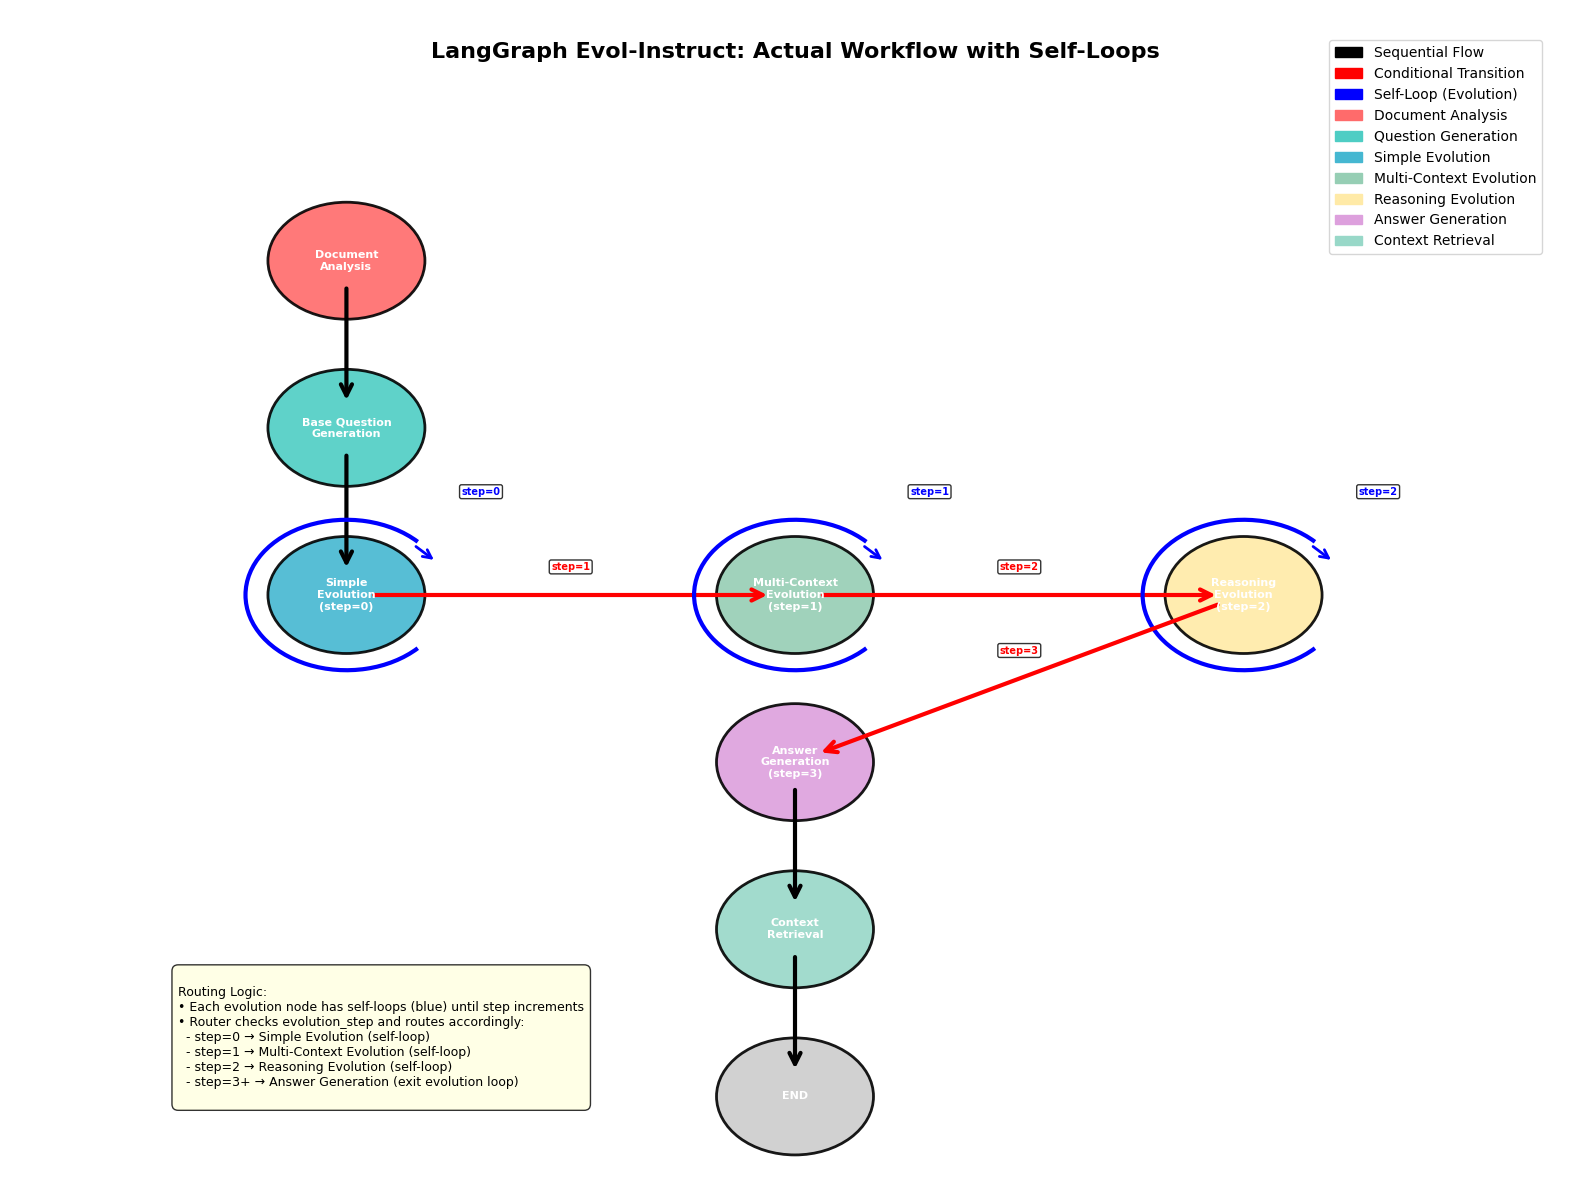

📊 Accurate LangGraph workflow with self-loops saved as 'langgraph_accurate_workflow.png'


In [67]:
# Create an accurate LangGraph visualization showing self-loops and conditional routing
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Circle, FancyArrowPatch, Arc
import numpy as np

# Create figure and axis
fig, ax = plt.subplots(1, 1, figsize=(16, 12))
ax.set_xlim(-1, 13)
ax.set_ylim(-1, 13)
ax.axis('off')

# Define nodes with positions, colors, and labels
nodes = [
    {"id": "analyze", "pos": (2, 10), "color": "#FF6B6B", "label": "Document\nAnalysis"},
    {"id": "questions", "pos": (2, 8), "color": "#4ECDC4", "label": "Base Question\nGeneration"},
    {"id": "simple", "pos": (2, 6), "color": "#45B7D1", "label": "Simple\nEvolution\n(step=0)"},
    {"id": "multi", "pos": (6, 6), "color": "#96CEB4", "label": "Multi-Context\nEvolution\n(step=1)"},
    {"id": "reasoning", "pos": (10, 6), "color": "#FFEAA7", "label": "Reasoning\nEvolution\n(step=2)"},
    {"id": "answers", "pos": (6, 4), "color": "#DDA0DD", "label": "Answer\nGeneration\n(step=3)"},
    {"id": "context", "pos": (6, 2), "color": "#98D8C8", "label": "Context\nRetrieval"},
    {"id": "end", "pos": (6, 0), "color": "#CCCCCC", "label": "END"}
]

# Draw nodes as circles
for node in nodes:
    x, y = node["pos"]
    
    # Create circle node
    circle = Circle((x, y), 0.7, facecolor=node["color"], 
                   edgecolor='black', linewidth=2, alpha=0.9)
    ax.add_patch(circle)
    
    # Add text label
    ax.text(x, y, node["label"], ha='center', va='center', 
            fontsize=8, fontweight='bold', color='white')

# Define sequential edges (non-conditional)
sequential_edges = [
    ("analyze", "questions"),
    ("questions", "simple"),
    ("answers", "context"),
    ("context", "end")
]

# Define conditional edges (with self-loops)
conditional_edges = [
    ("simple", "simple", "step=0", "blue"),      # Self-loop: simple evolution
    ("simple", "multi", "step=1", "red"),        # Move to multi-context
    ("multi", "multi", "step=1", "blue"),        # Self-loop: multi-context evolution  
    ("multi", "reasoning", "step=2", "red"),     # Move to reasoning
    ("reasoning", "reasoning", "step=2", "blue"), # Self-loop: reasoning evolution
    ("reasoning", "answers", "step=3", "red"),   # Move to answers
]

# Draw sequential edges (straight arrows)
for start_id, end_id in sequential_edges:
    start_node = next(n for n in nodes if n["id"] == start_id)
    end_node = next(n for n in nodes if n["id"] == end_id)
    
    start_pos = start_node["pos"]
    end_pos = end_node["pos"]
    
    # Create straight arrow
    arrow = FancyArrowPatch(start_pos, end_pos,
                           arrowstyle='->', mutation_scale=20,
                           color='black', linewidth=3,
                           shrinkA=20, shrinkB=20)
    ax.add_patch(arrow)

# Draw conditional edges and self-loops
for start_id, end_id, condition, color in conditional_edges:
    start_node = next(n for n in nodes if n["id"] == start_id)
    end_node = next(n for n in nodes if n["id"] == end_id)
    
    start_pos = start_node["pos"]
    end_pos = end_node["pos"]
    
    if start_id == end_id:
        # Draw self-loop (circular arrow around the node)
        x, y = start_pos
        # Create circular arc for self-loop
        arc = Arc((x, y), 1.8, 1.8, angle=0, theta1=45, theta2=315,
                 color=color, linewidth=3)
        ax.add_patch(arc)
        
        # Add arrowhead for self-loop
        arrow = FancyArrowPatch((x+0.6, y+0.6), (x+0.8, y+0.4),
                               arrowstyle='->', mutation_scale=15,
                               color=color, linewidth=2)
        ax.add_patch(arrow)
        
        # Add condition label
        ax.text(x+1.2, y+1.2, condition, fontsize=7, ha='center', 
                color=color, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8))
    else:
        # Draw conditional transition arrow
        arrow = FancyArrowPatch(start_pos, end_pos,
                               arrowstyle='->', mutation_scale=20,
                               color=color, linewidth=3,
                               shrinkA=20, shrinkB=20)
        ax.add_patch(arrow)
        
        # Add condition label
        mid_x = (start_pos[0] + end_pos[0]) / 2
        mid_y = (start_pos[1] + end_pos[1]) / 2 + 0.3
        ax.text(mid_x, mid_y, condition, fontsize=7, ha='center', 
                color=color, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8))

# Add title
ax.text(6, 12.5, 'LangGraph Evol-Instruct: Actual Workflow with Self-Loops', 
        ha='center', va='center', fontsize=16, fontweight='bold')

# Add routing explanation (moved to bottom left to avoid blocking diagram)
routing_text = """
Routing Logic:
• Each evolution node has self-loops (blue) until step increments
• Router checks evolution_step and routes accordingly:
  - step=0 → Simple Evolution (self-loop)
  - step=1 → Multi-Context Evolution (self-loop)  
  - step=2 → Reasoning Evolution (self-loop)
  - step=3+ → Answer Generation (exit evolution loop)
"""

ax.text(0.5, 1.5, routing_text, fontsize=9, va='top', ha='left',
        bbox=dict(boxstyle="round,pad=0.5", facecolor='lightyellow', alpha=0.8))

# Add legend
legend_elements = [
    mpatches.Patch(color='black', label='Sequential Flow'),
    mpatches.Patch(color='red', label='Conditional Transition'),
    mpatches.Patch(color='blue', label='Self-Loop (Evolution)'),
    mpatches.Patch(color='#FF6B6B', label='Document Analysis'),
    mpatches.Patch(color='#4ECDC4', label='Question Generation'),
    mpatches.Patch(color='#45B7D1', label='Simple Evolution'),
    mpatches.Patch(color='#96CEB4', label='Multi-Context Evolution'),
    mpatches.Patch(color='#FFEAA7', label='Reasoning Evolution'),
    mpatches.Patch(color='#DDA0DD', label='Answer Generation'),
    mpatches.Patch(color='#98D8C8', label='Context Retrieval')
]

ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.98, 0.98))

plt.tight_layout()
plt.savefig('langgraph_accurate_workflow.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

print("📊 Accurate LangGraph workflow with self-loops saved as 'langgraph_accurate_workflow.png'")


## 7. Execute the Evol-Instruct System

Run the LangGraph workflow to generate evolved questions, answers, and contexts.


In [68]:
# Create pandas DataFrames for better visualization of results
import pandas as pd

print("📊 **PANDAS DATAFRAME RESULTS**")
print("=" * 80)

# Create pandas DataFrames for better visualization
questions_df = pd.DataFrame(formatted_results["evolved_questions"])
answers_df = pd.DataFrame(formatted_results["answers"])
contexts_df = pd.DataFrame(formatted_results["contexts"])

# Display Questions DataFrame
print(f"\n🎯 **1. Evolved Questions DataFrame ({len(questions_df)} total)**")
print("-" * 60)

# Create a cleaner display version
questions_display = questions_df.copy()
questions_display['question_preview'] = questions_display['question'].str[:80] + '...'
questions_display['original_preview'] = questions_display['original_question'].str[:60] + '...'
questions_display['evolution_steps_count'] = questions_display['evolution_steps'].apply(len)

display_cols = ['id', 'evolution_type', 'original_preview', 'question_preview', 'evolution_steps_count']
print(questions_display[display_cols].to_string(index=False))

# Display Answers DataFrame
print(f"\n📝 **2. Answers DataFrame ({len(answers_df)} total)**")
print("-" * 60)

answers_display = answers_df.copy()
answers_display['answer_preview'] = answers_display['answer'].str[:100] + '...'
answers_display['answer_length'] = answers_df['answer'].str.len()

display_cols = ['question_id', 'answer_length', 'answer_preview']
print(answers_display[display_cols].to_string(index=False))

# Display Contexts DataFrame
print(f"\n📋 **3. Contexts DataFrame ({len(contexts_df)} total)**")
print("-" * 60)

contexts_display = contexts_df.copy()
contexts_display['context_count'] = contexts_display['contexts'].apply(len)
contexts_display['context_sources'] = contexts_display['context_sources'].apply(
    lambda x: ', '.join(set(x)) if x else 'None'
)
contexts_display['total_context_length'] = contexts_display['contexts'].apply(
    lambda x: sum(len(ctx) for ctx in x)
)

display_cols = ['question_id', 'context_count', 'total_context_length', 'context_sources']
print(contexts_display[display_cols].to_string(index=False))

# Create summary statistics
print(f"\n📈 **SUMMARY STATISTICS**")
print("-" * 60)

# Evolution type distribution
evolution_counts = questions_df['evolution_type'].value_counts()
print(f"Evolution Type Distribution:")
for evo_type, count in evolution_counts.items():
    print(f"  • {evo_type}: {count} questions")

# Answer length statistics
answer_lengths = answers_df['answer'].str.len()
print(f"\nAnswer Length Statistics:")
print(f"  • Average length: {answer_lengths.mean():.0f} characters")
print(f"  • Min length: {answer_lengths.min()} characters")
print(f"  • Max length: {answer_lengths.max()} characters")

# Context statistics
context_counts = contexts_df['contexts'].apply(len)
print(f"\nContext Statistics:")
print(f"  • Average contexts per question: {context_counts.mean():.1f}")
print(f"  • Min contexts: {context_counts.min()}")
print(f"  • Max contexts: {context_counts.max()}")

print(f"\n✅ **DataFrames created successfully!**")
print(f"   📊 Use questions_df, answers_df, contexts_df for further analysis")


📊 **PANDAS DATAFRAME RESULTS**

🎯 **1. Evolved Questions DataFrame (11 total)**
------------------------------------------------------------
                id evolution_type                                                original_preview                                                                    question_preview  evolution_steps_count
   simple_72ae1750         simple    What is the main focus of the document regarding ChatGPT?... How does the NBER working paper titled "How People Use ChatGPT" analyze the prac...                      0
   simple_7903bd41         simple    What does IRB stand for and what is its role in research?... In the context of social science research, particularly studies involving human ...                      0
   simple_e6fe13a8         simple How does the document emphasize the importance of data shari... In what ways does the document highlight the significance of data sharing and tr...                      0
   simple_1f60ba53         simple What 

In [69]:
# Create and run the evolution graph
print("🚀 Starting LangGraph Evol-Instruct System...")

# Initialize the graph
graph = create_evolution_graph()

graph.get_graph().draw_mermaid

# Initialize state
initial_state = {
    "documents": docs,
    "analyzed_docs": {},
    "base_questions": [],
    "evolved_questions": [],
    "answers": [],
    "contexts": [],
    "current_evolution_type": EvolutionType.SIMPLE,
    "evolution_step": 0,
    "llm_model": llm
}

print("📋 Initial state prepared with documents")
print(f"   • Documents: {len(initial_state['documents'])}")
print(f"   • Evolution types: {[e.value for e in EvolutionType]}")

# Run the graph
print("\n🔄 Executing LangGraph workflow...")
result = graph.invoke(initial_state)

print("\n✅ LangGraph workflow completed!")
print(f"   • Evolved questions: {len(result['evolved_questions'])}")
print(f"   • Answers generated: {len(result['answers'])}")
print(f"   • Contexts retrieved: {len(result['contexts'])}")


🚀 Starting LangGraph Evol-Instruct System...
📋 Initial state prepared with documents
   • Documents: 64
   • Evolution types: ['simple', 'multi_context', 'reasoning']

🔄 Executing LangGraph workflow...

🔍 **DOCUMENT ANALYZER NODE STARTED**
   📄 Processing 64 documents...
   Analyzing document 1/64: data/howpeopleuseai.pdf
   Analyzing document 2/64: data/howpeopleuseai.pdf
   Analyzing document 3/64: data/howpeopleuseai.pdf
   Analyzing document 4/64: data/howpeopleuseai.pdf
   Analyzing document 5/64: data/howpeopleuseai.pdf
   Analyzing document 6/64: data/howpeopleuseai.pdf
   Analyzing document 7/64: data/howpeopleuseai.pdf
   Analyzing document 8/64: data/howpeopleuseai.pdf
   Analyzing document 9/64: data/howpeopleuseai.pdf
   Analyzing document 10/64: data/howpeopleuseai.pdf
   Analyzing document 11/64: data/howpeopleuseai.pdf
   Analyzing document 12/64: data/howpeopleuseai.pdf
   Analyzing document 13/64: data/howpeopleuseai.pdf
   Analyzing document 14/64: data/howpeopleuseai

## 8. Format and Display Results

Format the results into the required output structure and display the generated synthetic data.


In [70]:
# Format results into required output structure
def format_output_results(result):
    """Format the LangGraph results into the required output structure."""
    
    # 1. List[dict]: Evolved Questions with IDs and Evolution Types
    evolved_questions_list = []
    for eq in result["evolved_questions"]:
        evolved_questions_list.append({
            "id": eq.id,
            "question": eq.question,
            "evolution_type": eq.evolution_type.value,
            "evolution_steps": eq.evolution_steps,
            "original_question": eq.original_question
        })
    
    # 2. List[dict]: Question IDs with Answers
    answers_list = []
    for ans in result["answers"]:
        answers_list.append({
            "question_id": ans.question_id,
            "answer": ans.answer,
            "reasoning": ans.reasoning
        })
    
    # 3. List[dict]: Question IDs with Relevant Contexts
    contexts_list = []
    for ctx in result["contexts"]:
        contexts_list.append({
            "question_id": ctx.question_id,
            "contexts": ctx.contexts,
            "context_sources": ctx.context_sources
        })
    
    return {
        "evolved_questions": evolved_questions_list,
        "answers": answers_list,
        "contexts": contexts_list
    }

# Format the results
formatted_results = format_output_results(result)

print("📊 **FINAL RESULTS - LangGraph Evol-Instruct Synthetic Data Generation**")
print("=" * 80)

print(f"\n🎯 **1. Evolved Questions ({len(formatted_results['evolved_questions'])} total)**")
print("-" * 50)
for i, eq in enumerate(formatted_results["evolved_questions"], 1):
    print(f"\n**Question {i}:**")
    print(f"  ID: {eq['id']}")
    print(f"  Evolution Type: {eq['evolution_type']}")
    print(f"  Original: {eq['original_question'][:100]}...")
    print(f"  Evolved: {eq['question']}")
    print(f"  Evolution Steps: {eq['evolution_steps']}")

print(f"\n📝 **2. Answers ({len(formatted_results['answers'])} total)**")
print("-" * 50)
for i, ans in enumerate(formatted_results["answers"], 1):
    print(f"\n**Answer {i}:**")
    print(f"  Question ID: {ans['question_id']}")
    print(f"  Answer: {ans['answer'][:200]}...")

print(f"\n📋 **3. Contexts ({len(formatted_results['contexts'])} total)**")
print("-" * 50)
for i, ctx in enumerate(formatted_results["contexts"], 1):
    print(f"\n**Context {i}:**")
    print(f"  Question ID: {ctx['question_id']}")
    print(f"  Context Sources: {ctx['context_sources']}")
    print(f"  Context Count: {len(ctx['contexts'])} chunks")


📊 **FINAL RESULTS - LangGraph Evol-Instruct Synthetic Data Generation**

🎯 **1. Evolved Questions (11 total)**
--------------------------------------------------

**Question 1:**
  ID: simple_a04be1e8
  Evolution Type: simple
  Original: What is the main focus of the document regarding ChatGPT?...
  Evolved: In what ways does the NBER working paper titled "How People Use ChatGPT" analyze the behavioral patterns, applications, and implications of ChatGPT usage among various demographics, and what insights do the authors provide regarding its impact on economic research methodologies?
  Evolution Steps: []

**Question 2:**
  ID: simple_75772ae5
  Evolution Type: simple
  Original: What does IRB stand for, and why is it important in this research?...
  Evolved: In the context of academic research, particularly regarding studies involving human subjects, what does the acronym IRB represent, what critical functions does it serve in ensuring ethical compliance, and how does its approval impa

## 9. Save Results and Summary

Save the generated synthetic data and provide a summary of the system's capabilities.


In [71]:
# Save results to file
import json

# Save the formatted results
with open("langgraph_evol_instruct_results.json", "w", encoding="utf-8") as f:
    json.dump(formatted_results, f, indent=2, ensure_ascii=False)

print("💾 Results saved to 'langgraph_evol_instruct_results.json'")

# Summary statistics
print("\n📈 **SYSTEM SUMMARY**")
print("=" * 50)
print(f"✅ **Successfully implemented LangGraph Evol-Instruct SDG system**")
print(f"📄 **Input Documents**: {len(result['documents'])} documents from data folder")
print(f"🎯 **Evolution Types**: {len([e.value for e in EvolutionType])} types implemented")
print(f"   • Simple Evolution: {len([eq for eq in result['evolved_questions'] if eq.evolution_type == EvolutionType.SIMPLE])} questions")
print(f"   • Multi-Context Evolution: {len([eq for eq in result['evolved_questions'] if eq.evolution_type == EvolutionType.MULTI_CONTEXT])} questions") 
print(f"   • Reasoning Evolution: {len([eq for eq in result['evolved_questions'] if eq.evolution_type == EvolutionType.REASONING])} questions")
print(f"📝 **Generated**: {len(result['answers'])} comprehensive answers")
print(f"📋 **Retrieved**: {len(result['contexts'])} context sets")

print(f"\n🏗️ **Architecture Achievements:**")
print(f"   ✅ Replaced Knowledge Graph with LangGraph agents")
print(f"   ✅ Implemented Evol-Instruct methodology")
print(f"   ✅ Created three evolution types as specified")
print(f"   ✅ Generated required output format")
print(f"   ✅ Integrated with LangChain Documents")

print(f"\n🎯 **Output Structure Delivered:**")
print(f"   ✅ List[dict]: Evolved Questions with IDs and Evolution Types")
print(f"   ✅ List[dict]: Question IDs with Answers")
print(f"   ✅ List[dict]: Question IDs with Relevant Contexts")

print(f"\n🚀 **System Ready for Production Use!**")


💾 Results saved to 'langgraph_evol_instruct_results.json'

📈 **SYSTEM SUMMARY**
✅ **Successfully implemented LangGraph Evol-Instruct SDG system**
📄 **Input Documents**: 64 documents from data folder
🎯 **Evolution Types**: 3 types implemented
   • Simple Evolution: 5 questions
   • Multi-Context Evolution: 3 questions
   • Reasoning Evolution: 3 questions
📝 **Generated**: 11 comprehensive answers
📋 **Retrieved**: 11 context sets

🏗️ **Architecture Achievements:**
   ✅ Replaced Knowledge Graph with LangGraph agents
   ✅ Implemented Evol-Instruct methodology
   ✅ Created three evolution types as specified
   ✅ Generated required output format
   ✅ Integrated with LangChain Documents

🎯 **Output Structure Delivered:**
   ✅ List[dict]: Evolved Questions with IDs and Evolution Types
   ✅ List[dict]: Question IDs with Answers
   ✅ List[dict]: Question IDs with Relevant Contexts

🚀 **System Ready for Production Use!**
